In [1]:
!pip install networkx -q

In [2]:
import pandas as pd
import numpy as np

import networkx as nx

import matplotlib.pyplot as plt

import os

plt.style.use("ggplot")

print("Libraries Loaded.")

Libraries Loaded.


In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
file_path="/content/Dataset_B_Country_Features (2).csv"

df=pd.read_csv(file_path)

display(df.head())

,Continent,Country,Date of First Case(s),Last Visited Country(s) of Confirmed Case(s),Confirmed Case(s) at First Day,Age of First Case(s),Date of First Death(s),Age of First Death(s),Days_Since_Global_First_Case,First_Case_Month,...,First_Case_DayOfYear,First_Case_Quarter,First_Case_Year,Has_Travel_Origin,Origin_Count,Multiple_Origins,Origin,Death_Recorded,Days_To_First_Death,Multiple_First_Day_Cases
0,Asia,China,2019-11-17,Starting Country,1,55,NaN,NaN,0,11,...,321,4,2019,True,1,False,Starting Country,False,NaN,False
1,Europe,France,2019-12-27,NaN,1,43,2020-02-15,80,40,12,...,361,4,2019,False,0,False,NaN,True,50.0,False
2,Asia,Nepal,2020-01-13,China,1,32,2020-05-16,29,57,1,...,13,1,2020,True,1,False,China,True,124.0,False
3,Asia,Thailand,2020-01-13,China,1,61,2020-03-01,35,57,1,...,13,1,2020,True,1,False,China,True,48.0,False
4,Asia,Japan,2020-01-16,China,1,30+,2020-02-13,80+,60,1,...,16,1,2020,True,1,False,China,True,28.0,False


In [5]:
output_folder="/content/drive/MyDrive/COVID/TransmissionPath"

tables_folder=os.path.join(output_folder,"Tables")

figures_folder=os.path.join(output_folder,"Figures")

os.makedirs(tables_folder,exist_ok=True)

os.makedirs(figures_folder,exist_ok=True)

In [8]:
graph_df=df[
    ["Origin","Country"]
].copy()

graph_df=graph_df.dropna()

graph_df=graph_df[
    graph_df["Origin"]!="Unknown"
]

display(graph_df.head())

,Origin,Country
0,Starting Country,China
2,China,Nepal
3,China,Thailand
4,China,Japan
5,China,South Korea


In [10]:
G=nx.DiGraph()

for _,row in graph_df.iterrows():

    origin=row["Origin"]

    destination=row["Country"]

    if G.has_edge(origin,destination):

        G[origin][destination]["weight"]+=1

    else:

        G.add_edge(origin,destination,weight=1)

In [ ]:
print("="*60)

print("Transmission Graph Summary")

print("="*60)

print("Nodes :",G.number_of_nodes())

print("Edges :",G.number_of_edges())

print("Density :",nx.density(G))

Transmission Graph Summary
Nodes : 177
Edges : 173
Density : 0.00555341551104263


In [11]:
edges=[]

for u,v,d in G.edges(data=True):

    edges.append([

        u,

        v,

        d["weight"]

    ])

edges_df=pd.DataFrame(

    edges,

    columns=[

        "Origin",

        "Destination",

        "Weight"

    ]

)

display(edges_df.head())

edges_df.to_csv(

    os.path.join(

        tables_folder,

        "TransmissionEdges.csv"

    ),

    index=False

)

,Origin,Destination,Weight
0,Starting Country,China,1
1,China,Nepal,1
2,China,Thailand,1
3,China,Japan,1
4,China,South Korea,1


In [12]:
source_degree=dict(G.out_degree())

source_df=pd.DataFrame({

    "Country":list(source_degree.keys()),

    "OutgoingLinks":list(source_degree.values())

})

source_df=source_df.sort_values(

    "OutgoingLinks",

    ascending=False

)

display(source_df.head(20))

source_df.to_csv(

    os.path.join(

        tables_folder,

        "MajorSourceCountries.csv"

    ),

    index=False

)

,Country,OutgoingLinks
19,Italy,50
1,China,25
23,Iran,17
20,United Kingdom,15
65,France,14
22,Spain,10
6,United States,10
14,Germany,4
37,Switzerland,4
16,United Arab Emirates,4


In [13]:
destination_degree=dict(G.in_degree())

destination_df=pd.DataFrame({

    "Country":list(destination_degree.keys()),

    "IncomingLinks":list(destination_degree.values())

})

destination_df=destination_df.sort_values(

    "IncomingLinks",

    ascending=False

)

display(destination_df.head(20))

destination_df.to_csv(

    os.path.join(

        tables_folder,

        "MajorDestinationCountries.csv"

    ),

    index=False

)

,Country,IncomingLinks
85,Togo,4
81,West Bank and Gaza,3
153,Niger,3
92,Peru,3
142,Montenegro,2
129,Kenya,2
76,Ukraine,2
114,Ghana,2
107,Honduras,2
101,Cyprus,2


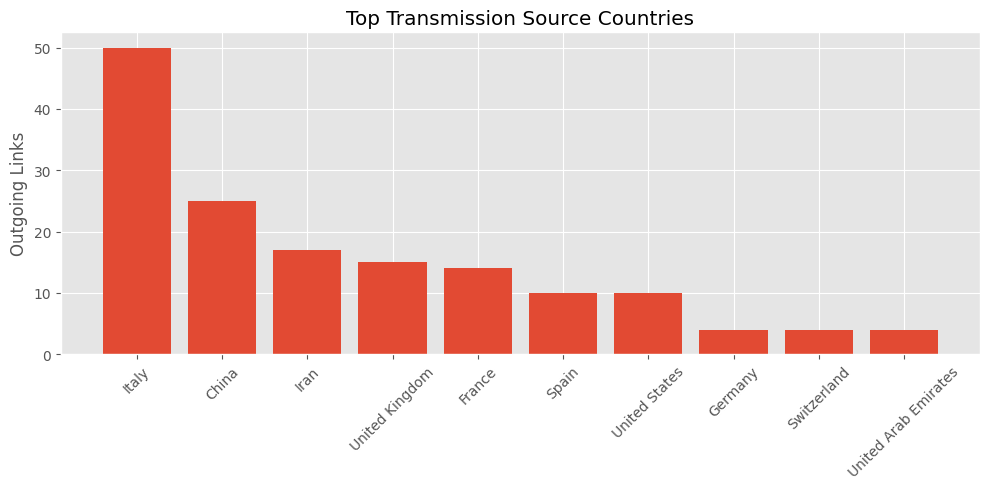

In [14]:
top10=source_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(

    top10["Country"],

    top10["OutgoingLinks"]

)

plt.xticks(rotation=45)

plt.ylabel("Outgoing Links")

plt.title("Top Transmission Source Countries")

plt.tight_layout()

plt.savefig(

    os.path.join(

        figures_folder,

        "TopSources.pdf"

    ),

    dpi=300

)

plt.savefig(

    os.path.join(

        figures_folder,

        "TopSources.png"

    ),

    dpi=300

)

plt.show()

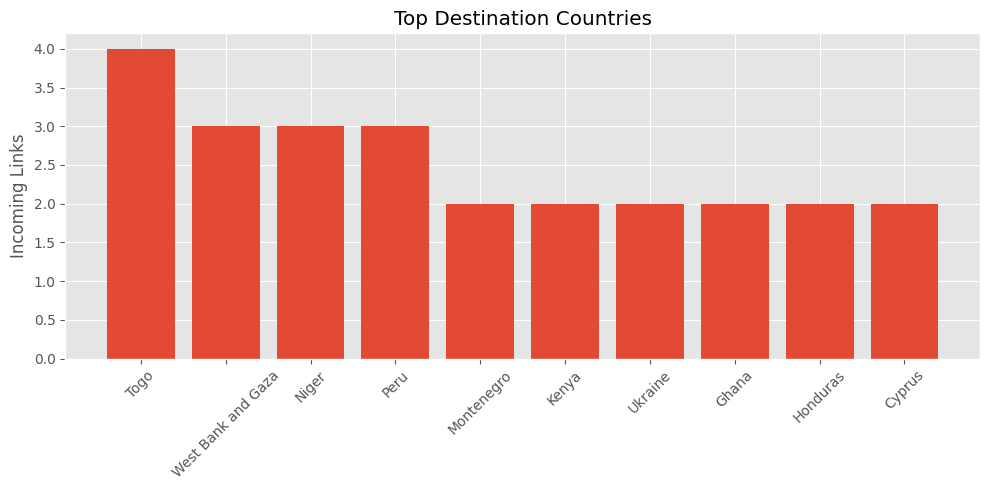

In [15]:
top10=destination_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(

    top10["Country"],

    top10["IncomingLinks"]

)

plt.xticks(rotation=45)

plt.ylabel("Incoming Links")

plt.title("Top Destination Countries")

plt.tight_layout()

plt.savefig(

    os.path.join(

        figures_folder,

        "TopDestinations.pdf"

    ),

    dpi=300

)

plt.savefig(

    os.path.join(

        figures_folder,

        "TopDestinations.png"

    ),

    dpi=300

)

plt.show()

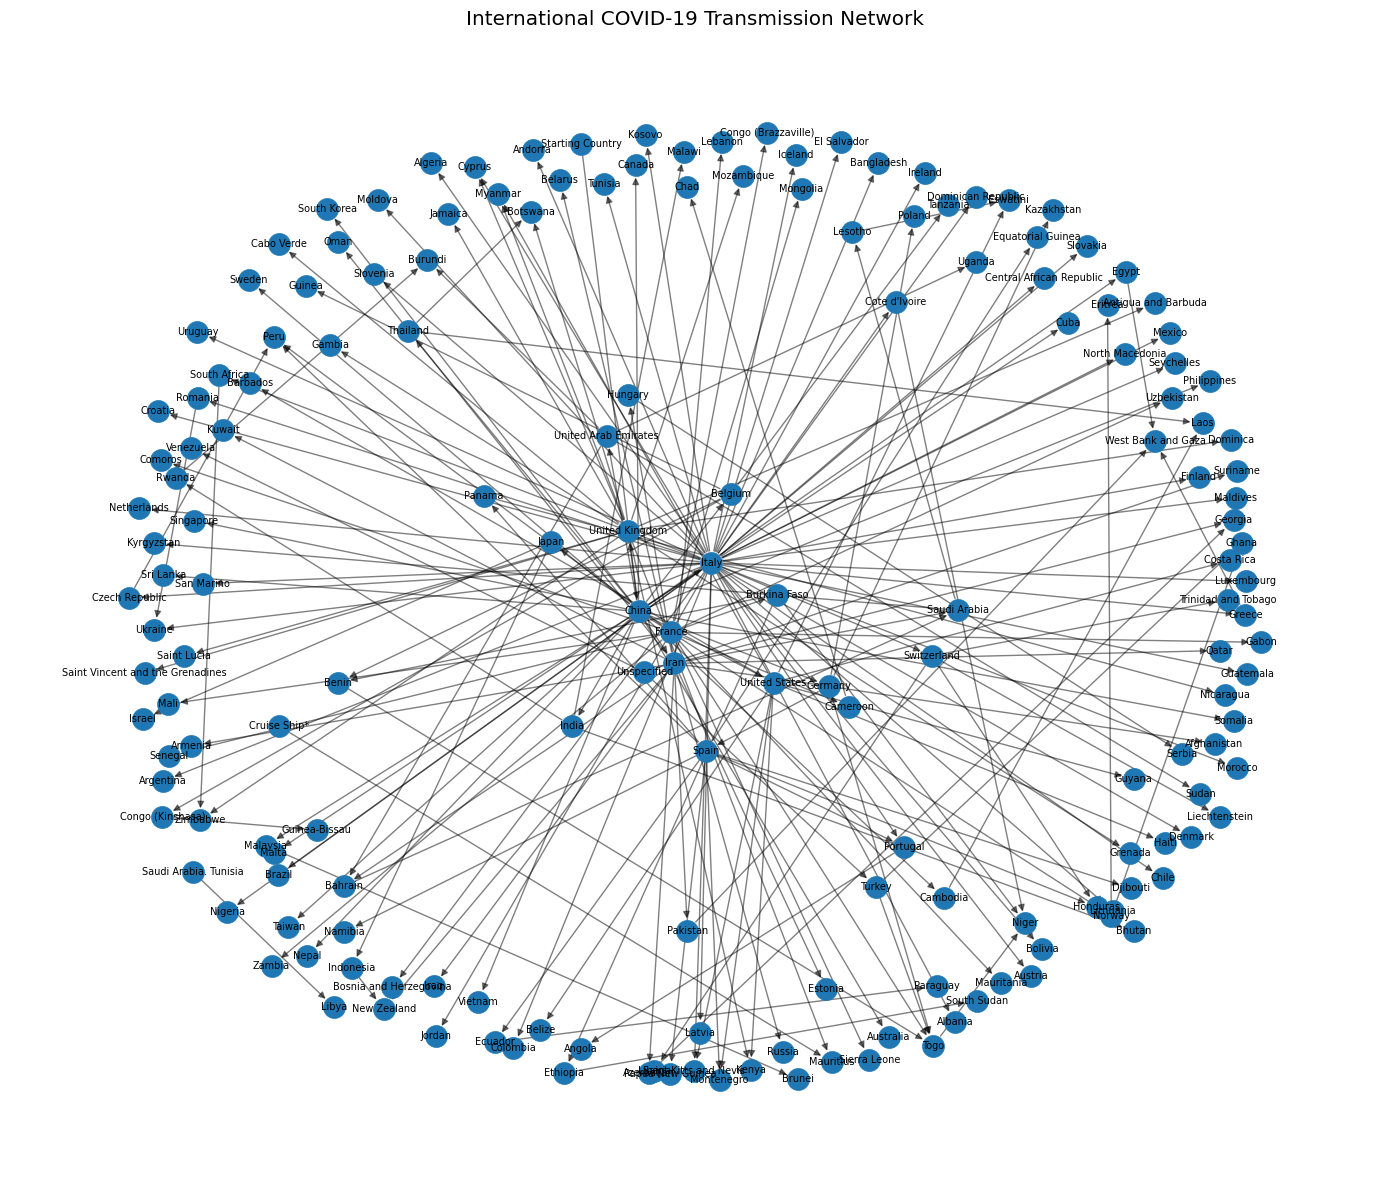

In [16]:
plt.figure(figsize=(14,12))

pos=nx.spring_layout(G,k=0.7,seed=42)

nx.draw_networkx_nodes(

    G,

    pos,

    node_size=250

)

nx.draw_networkx_edges(

    G,

    pos,

    arrows=True,

    alpha=0.5

)

nx.draw_networkx_labels(

    G,

    pos,

    font_size=7

)

plt.title("International COVID-19 Transmission Network")

plt.axis("off")

plt.tight_layout()

plt.savefig(

    os.path.join(

        figures_folder,

        "TransmissionNetwork.pdf"

    ),

    dpi=300

)

plt.savefig(

    os.path.join(

        figures_folder,

        "TransmissionNetwork.png"

    ),

    dpi=300

)

plt.show()

In [17]:
degree_centrality = nx.degree_centrality(G)

degree_df = pd.DataFrame({
    "Country": list(degree_centrality.keys()),
    "DegreeCentrality": list(degree_centrality.values())
})

degree_df = degree_df.sort_values(
    by="DegreeCentrality",
    ascending=False
)

display(degree_df.head(20))

degree_df.to_csv(
    os.path.join(
        tables_folder,
        "DegreeCentrality.csv"
    ),
    index=False
)

,Country,DegreeCentrality
19,Italy,0.288136
1,China,0.146893
23,Iran,0.101695
20,United Kingdom,0.090395
65,France,0.079096
22,Spain,0.062147
6,United States,0.062147
14,Germany,0.028249
37,Switzerland,0.028249
16,United Arab Emirates,0.028249


In [18]:
betweenness = nx.betweenness_centrality(
    G,
    normalized=True
)

betweenness_df = pd.DataFrame({

    "Country": list(betweenness.keys()),

    "Betweenness": list(betweenness.values())

})

betweenness_df = betweenness_df.sort_values(
    by="Betweenness",
    ascending=False
)

display(betweenness_df.head(20))

betweenness_df.to_csv(

    os.path.join(
        tables_folder,
        "BetweennessCentrality.csv"
    ),

    index=False
)

,Country,Betweenness
1,China,0.004911
19,Italy,0.003499
23,Iran,0.001252
22,Spain,0.000995
14,Germany,0.000867
20,United Kingdom,0.000835
6,United States,0.000546
67,Saudi Arabia,0.000417
37,Switzerland,0.000353
25,Belgium,0.000321


In [19]:
closeness = nx.closeness_centrality(G)

closeness_df = pd.DataFrame({

    "Country": list(closeness.keys()),

    "Closeness": list(closeness.values())

})

closeness_df = closeness_df.sort_values(
    by="Closeness",
    ascending=False
)

display(closeness_df.head(20))

closeness_df.to_csv(

    os.path.join(
        tables_folder,
        "ClosenessCentrality.csv"
    ),

    index=False
)

,Country,Closeness
153,Niger,0.031291
85,Togo,0.030508
81,West Bank and Gaza,0.023070
92,Peru,0.019774
136,Eswatini,0.019031
84,Benin,0.015694
54,New Zealand,0.015694
67,Saudi Arabia,0.015694
142,Montenegro,0.015694
114,Ghana,0.015694


In [20]:
try:

    eigen = nx.eigenvector_centrality(
        G,
        max_iter=1000
    )

    eigen_df = pd.DataFrame({

        "Country": list(eigen.keys()),

        "Eigenvector": list(eigen.values())

    })

    eigen_df = eigen_df.sort_values(
        by="Eigenvector",
        ascending=False
    )

    display(eigen_df.head(20))

    eigen_df.to_csv(

        os.path.join(
            tables_folder,
            "EigenvectorCentrality.csv"
        ),

        index=False
    )

except:

    print("Eigenvector Centrality could not be computed.")

,Country,Eigenvector
136,Eswatini,0.999639
137,Lesotho,0.015477
147,Kyrgyzstan,0.015477
153,Niger,0.007987
158,Angola,0.007788
94,Paraguay,0.007689
146,Nicaragua,0.007689
81,West Bank and Gaza,0.000199
67,Saudi Arabia,0.000199
92,Peru,0.000198


In [21]:
UG = G.to_undirected()

communities = list(
    nx.community.greedy_modularity_communities(UG)
)

community_list = []

for i, community in enumerate(communities):

    for country in community:

        community_list.append([

            country,

            i + 1

        ])

community_df = pd.DataFrame(

    community_list,

    columns=[

        "Country",

        "Community"

    ]

)

display(community_df.head(20))

community_df.to_csv(

    os.path.join(

        tables_folder,

        "Communities.csv"

    ),

    index=False
)

,Country,Community
0,Morocco,1
1,Maldives,1
2,Bolivia,1
3,Algeria,1
4,Moldova,1
5,Latvia,1
6,Ireland,1
7,Iceland,1
8,Albania,1
9,Seychelles,1


In [22]:
components = list(
    nx.connected_components(UG)
)

print("Number of Connected Components:", len(components))

component_sizes = [len(c) for c in components]

print(component_sizes)

Number of Connected Components: 2
[176, 2]


In [23]:
largest = max(
    components,
    key=len
)

largest_graph = UG.subgraph(
    largest
)

print("Largest Component Size")

print(
    largest_graph.number_of_nodes()
)

Largest Component Size
176


In [24]:
paths = []

for source in G.nodes():

    for target in G.nodes():

        if source != target:

            try:

                p = nx.shortest_path(

                    G,

                    source,

                    target

                )

                if len(p) >= 3:

                    paths.append(p)

            except:

                pass

print("Transmission Paths Found")

print(len(paths))

Transmission Paths Found
337


In [25]:
paths = sorted(

    paths,

    key=len,

    reverse=True

)

longest = paths[:20]

chain_df = pd.DataFrame({

    "TransmissionChain":[

        " → ".join(x)

        for x in longest

    ],

    "Length":[

        len(x)

        for x in longest

    ]

})

display(chain_df)

chain_df.to_csv(

    os.path.join(

        tables_folder,

        "LongestTransmissionChains.csv"

    ),

    index=False
)

,TransmissionChain,Length
0,Starting Country → China → Germany → Spain → E...,6
1,Starting Country → China → Germany → Spain → P...,6
2,Starting Country → China → Germany → Spain → E...,5
3,Starting Country → China → Italy → Switzerland...,5
4,Starting Country → China → Iran → Hungary → Se...,5
5,Starting Country → China → Germany → Spain → Peru,5
6,Starting Country → China → Germany → Spain → P...,5
7,Starting Country → China → Germany → Spain → H...,5
8,Starting Country → China → Italy → Switzerland...,5
9,Starting Country → China → Germany → Spain → N...,5


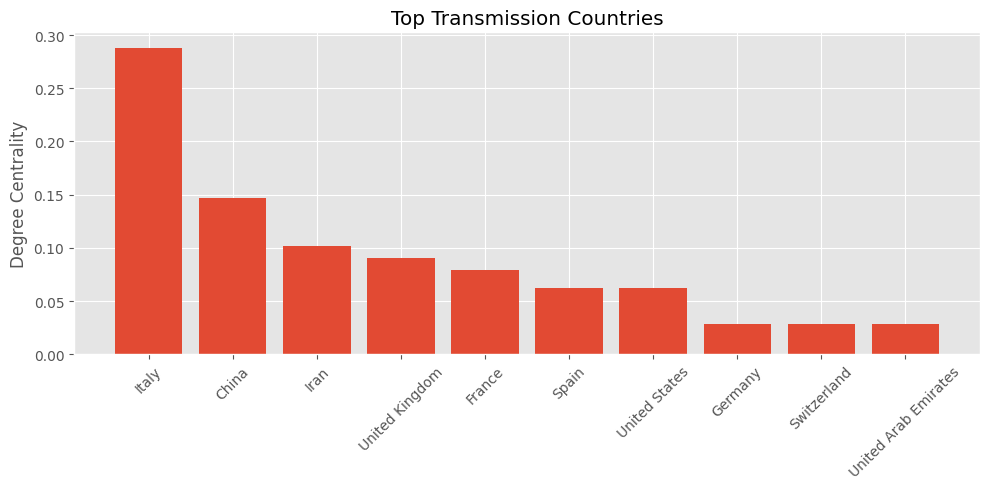

In [26]:
top = degree_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(

    top["Country"],

    top["DegreeCentrality"]

)

plt.xticks(rotation=45)

plt.ylabel("Degree Centrality")

plt.title("Top Transmission Countries")

plt.tight_layout()

plt.savefig(

    os.path.join(

        figures_folder,

        "TopCentralCountries.pdf"

    ),

    dpi=300

)

plt.savefig(

    os.path.join(

        figures_folder,

        "TopCentralCountries.png"

    ),

    dpi=300

)

plt.show()

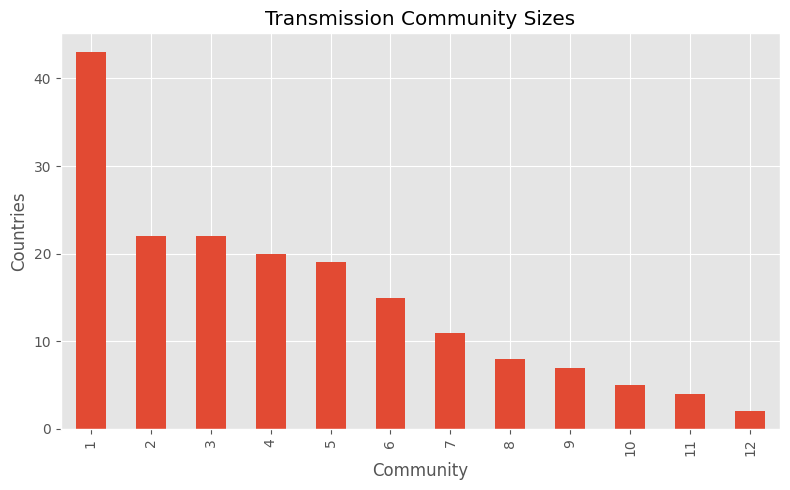

In [27]:
community_sizes = community_df["Community"].value_counts().sort_index()

plt.figure(figsize=(8,5))

community_sizes.plot(kind="bar")

plt.xlabel("Community")

plt.ylabel("Countries")

plt.title("Transmission Community Sizes")

plt.tight_layout()

plt.savefig(

    os.path.join(

        figures_folder,

        "CommunitySizes.pdf"

    ),

    dpi=300

)

plt.savefig(

    os.path.join(

        figures_folder,

        "CommunitySizes.png"

    ),

    dpi=300

)

plt.show()

In [28]:
print("=" * 60)

print("TRANSMISSION PATH ANALYSIS SUMMARY")

print("=" * 60)

print("Nodes:", G.number_of_nodes())

print("Edges:", G.number_of_edges())

print("Communities:", len(communities))

print("Connected Components:", len(components))

print("Longest Chain Length:")

if len(chain_df) > 0:

    print(chain_df["Length"].max())

else:

    print("No transmission chains found.")

TRANSMISSION PATH ANALYSIS SUMMARY
Nodes: 178
Edges: 202
Communities: 12
Connected Components: 2
Longest Chain Length:
6
